# Notebook 04 — Trajectory Analysis (PAGA + Pseudotime)

**Goal:** Reconstruct the differentiation trajectory of hematopoietic cells and identify at which stage malignant AML cells are blocked.

## Biological context

**Normal hematopoiesis:** HSC → Progenitors → GMP → Monocytes (progressive differentiation)  
**AML:** This process is interrupted. Malignant cells are "frozen" at an early progenitor stage and accumulate.

By computing **pseudotime** (an ordering of cells along a differentiation axis), we can:
- Confirm the normal hematopoiesis trajectory
- Show where malignant cells cluster along this axis
- Compare AML patients vs healthy donors

## Methods

- **PAGA (Partition-based Graph Abstraction):** Builds a connectivity graph between cell type clusters. Shows which populations are transcriptionally connected.
- **DPT (Diffusion Pseudotime):** Orders cells along a continuous trajectory starting from a root cell (HSC). Based on diffusion maps.


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.utils import (
    run_paga,
    run_diffusion_pseudotime,
    set_plot_style
)

set_plot_style()
sc.settings.verbosity = 1

In [2]:
# Load annotated data from notebook 03
adata = sc.read('../data/raw/adata_03_annotated.h5ad')
print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Cell types: {adata.obs['predicted_cell_type'].unique().tolist()}")

Loaded: 5996 cells × 17897 genes
Cell types: ['Promono', 'Progenitor', 'Erythroid', 'Mono', 'T cell', 'GMP', 'cDC', 'Malignant', 'pDC', 'Platelet MEP', 'B cell', 'NK cell', 'HSC']


## 4.1 — PAGA: Cell Type Connectivity Graph

PAGA computes a graph where:
- **Nodes** = cell type clusters
- **Edge thickness** = transcriptional connectivity between clusters

Expected result for normal hematopoiesis: a linear trajectory  
HSC → Progenitor → GMP → Promono → Mono  
with branches for Erythroid and Platelet/MEP lineages.

PAGA computed on 'predicted_cell_type'


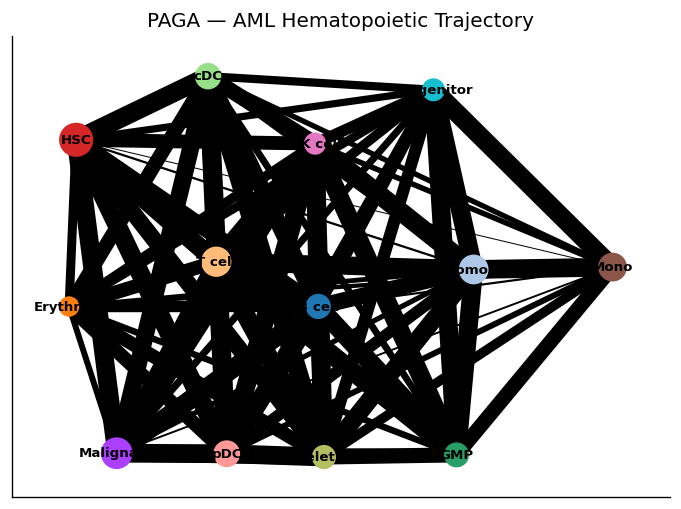

<Figure size 768x576 with 0 Axes>

In [3]:
# Run PAGA on predicted cell types
adata = run_paga(adata, group_key='predicted_cell_type')

# Plot PAGA graph
sc.pl.paga(
    adata,
    color='predicted_cell_type',
    title='PAGA — AML Hematopoietic Trajectory',
    threshold=0.05,
    node_size_scale=1.5,
    edge_width_scale=1.5,
    fontsize=8
)
plt.savefig('../figures/04_paga_graph.png', dpi=150, bbox_inches='tight')

/Users/jess/Documents/Data Projects/Projets Github/.venv-aml-tcga/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


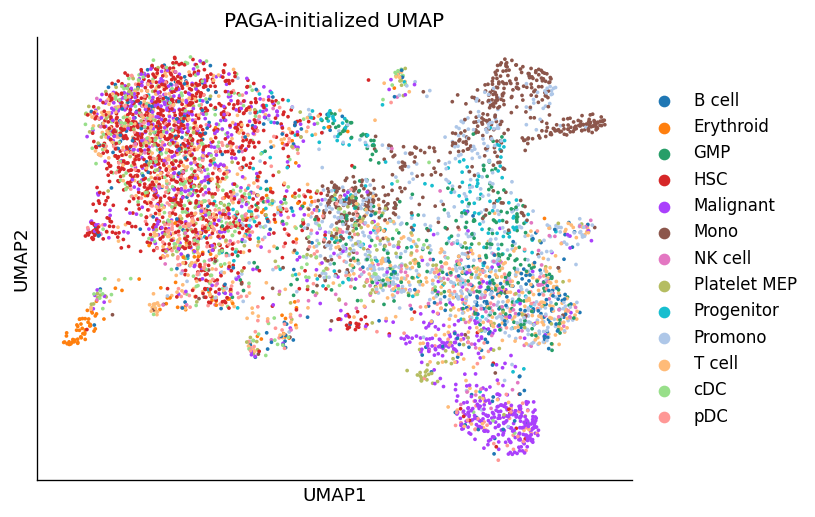

<Figure size 768x576 with 0 Axes>

In [4]:
# PAGA-initialized UMAP — better preserves trajectory structure
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(
    adata,
    color='predicted_cell_type',
    title='PAGA-initialized UMAP',
    legend_loc='right margin'
)
plt.savefig('../figures/04_umap_paga_init.png', dpi=150, bbox_inches='tight')

## 4.2 — Diffusion Pseudotime (DPT)

DPT places each cell on a continuous axis from 0 (root: HSC) to 1 (terminal state).  
This allows us to ask: *at what pseudotime do malignant cells accumulate?*

We set the root to the HSC population, since this is the origin of normal hematopoiesis.

In [5]:
# Run diffusion pseudotime from HSC as root
adata = run_diffusion_pseudotime(
    adata,
    root_cell_type='HSC',
    cell_type_key='predicted_cell_type'
)

DPT computed from root='HSC'


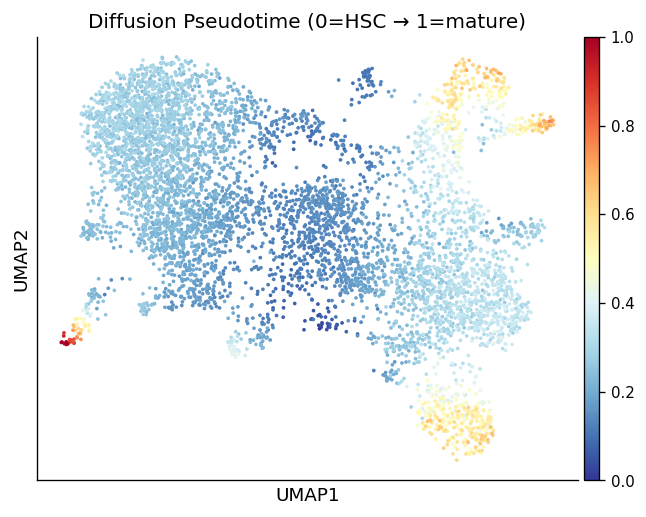

<Figure size 768x576 with 0 Axes>

In [6]:
# UMAP colored by pseudotime
sc.pl.umap(
    adata,
    color='dpt_pseudotime',
    title='Diffusion Pseudotime (0=HSC → 1=mature)',
    color_map='RdYlBu_r'
)
plt.savefig('../figures/04_umap_pseudotime.png', dpi=150, bbox_inches='tight')

/var/folders/cv/9vy8yk7x1s73_8cbwdkqfldh0000gn/T/ipykernel_22233/3155259194.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('predicted_cell_type')['dpt_pseudotime']


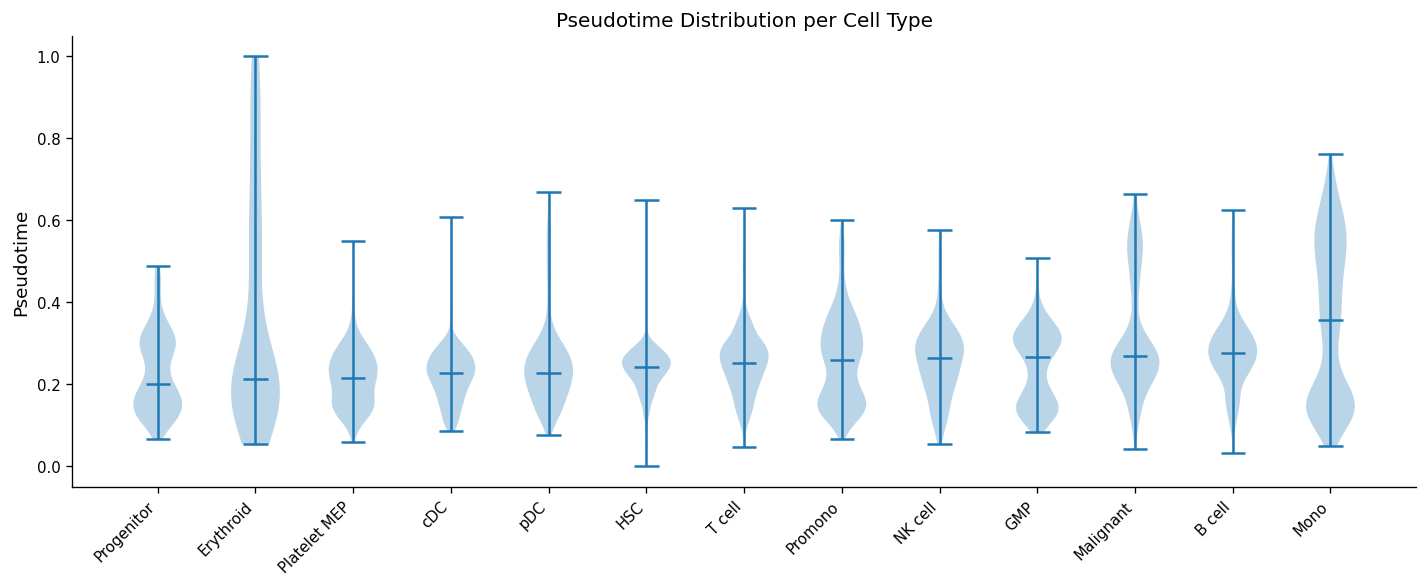

In [7]:
# Pseudotime distribution per cell type (violin)
fig, ax = plt.subplots(figsize=(12, 5))

cell_types_ordered = (
    adata.obs.groupby('predicted_cell_type')['dpt_pseudotime']
    .median()
    .sort_values()
    .index.tolist()
)

data_per_type = [
    adata.obs.loc[adata.obs['predicted_cell_type'] == ct, 'dpt_pseudotime'].values
    for ct in cell_types_ordered
]

ax.violinplot(data_per_type, positions=range(len(cell_types_ordered)), showmedians=True)
ax.set_xticks(range(len(cell_types_ordered)))
ax.set_xticklabels(cell_types_ordered, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Pseudotime')
ax.set_title('Pseudotime Distribution per Cell Type')
plt.tight_layout()
plt.savefig('../figures/04_pseudotime_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 — AML vs Healthy: Where Are Malignant Cells Blocked?

Compare pseudotime distributions between AML patients and healthy donors.  
If malignant cells are blocked at early progenitor stage, they should show **lower pseudotime** values compared to healthy cells.

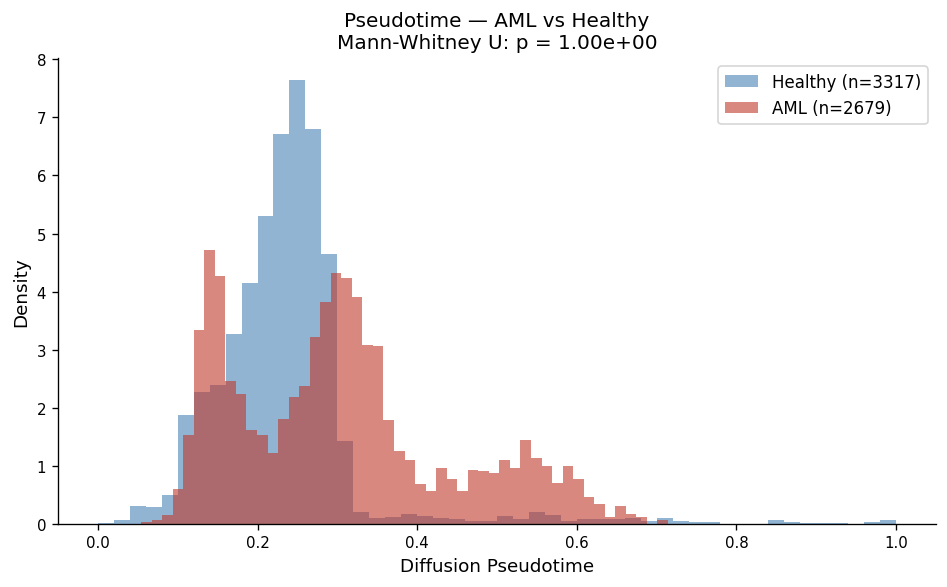

Median pseudotime — AML: 0.294 | Healthy: 0.234
Mann-Whitney U test: p = 1.00e+00


In [8]:
from scipy import stats

aml_pseudotime    = adata.obs.loc[adata.obs['is_aml'],  'dpt_pseudotime'].dropna()
healthy_pseudotime = adata.obs.loc[~adata.obs['is_aml'], 'dpt_pseudotime'].dropna()

stat, pval = stats.mannwhitneyu(aml_pseudotime, healthy_pseudotime, alternative='less')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(healthy_pseudotime, bins=50, alpha=0.6, label=f'Healthy (n={len(healthy_pseudotime)})', color='steelblue', density=True)
ax.hist(aml_pseudotime,     bins=50, alpha=0.6, label=f'AML (n={len(aml_pseudotime)})',     color='#c0392b',  density=True)
ax.set_xlabel('Diffusion Pseudotime')
ax.set_ylabel('Density')
ax.set_title(f'Pseudotime — AML vs Healthy\nMann-Whitney U: p = {pval:.2e}')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/04_pseudotime_aml_vs_healthy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median pseudotime — AML: {aml_pseudotime.median():.3f} | Healthy: {healthy_pseudotime.median():.3f}")
print(f"Mann-Whitney U test: p = {pval:.2e}")

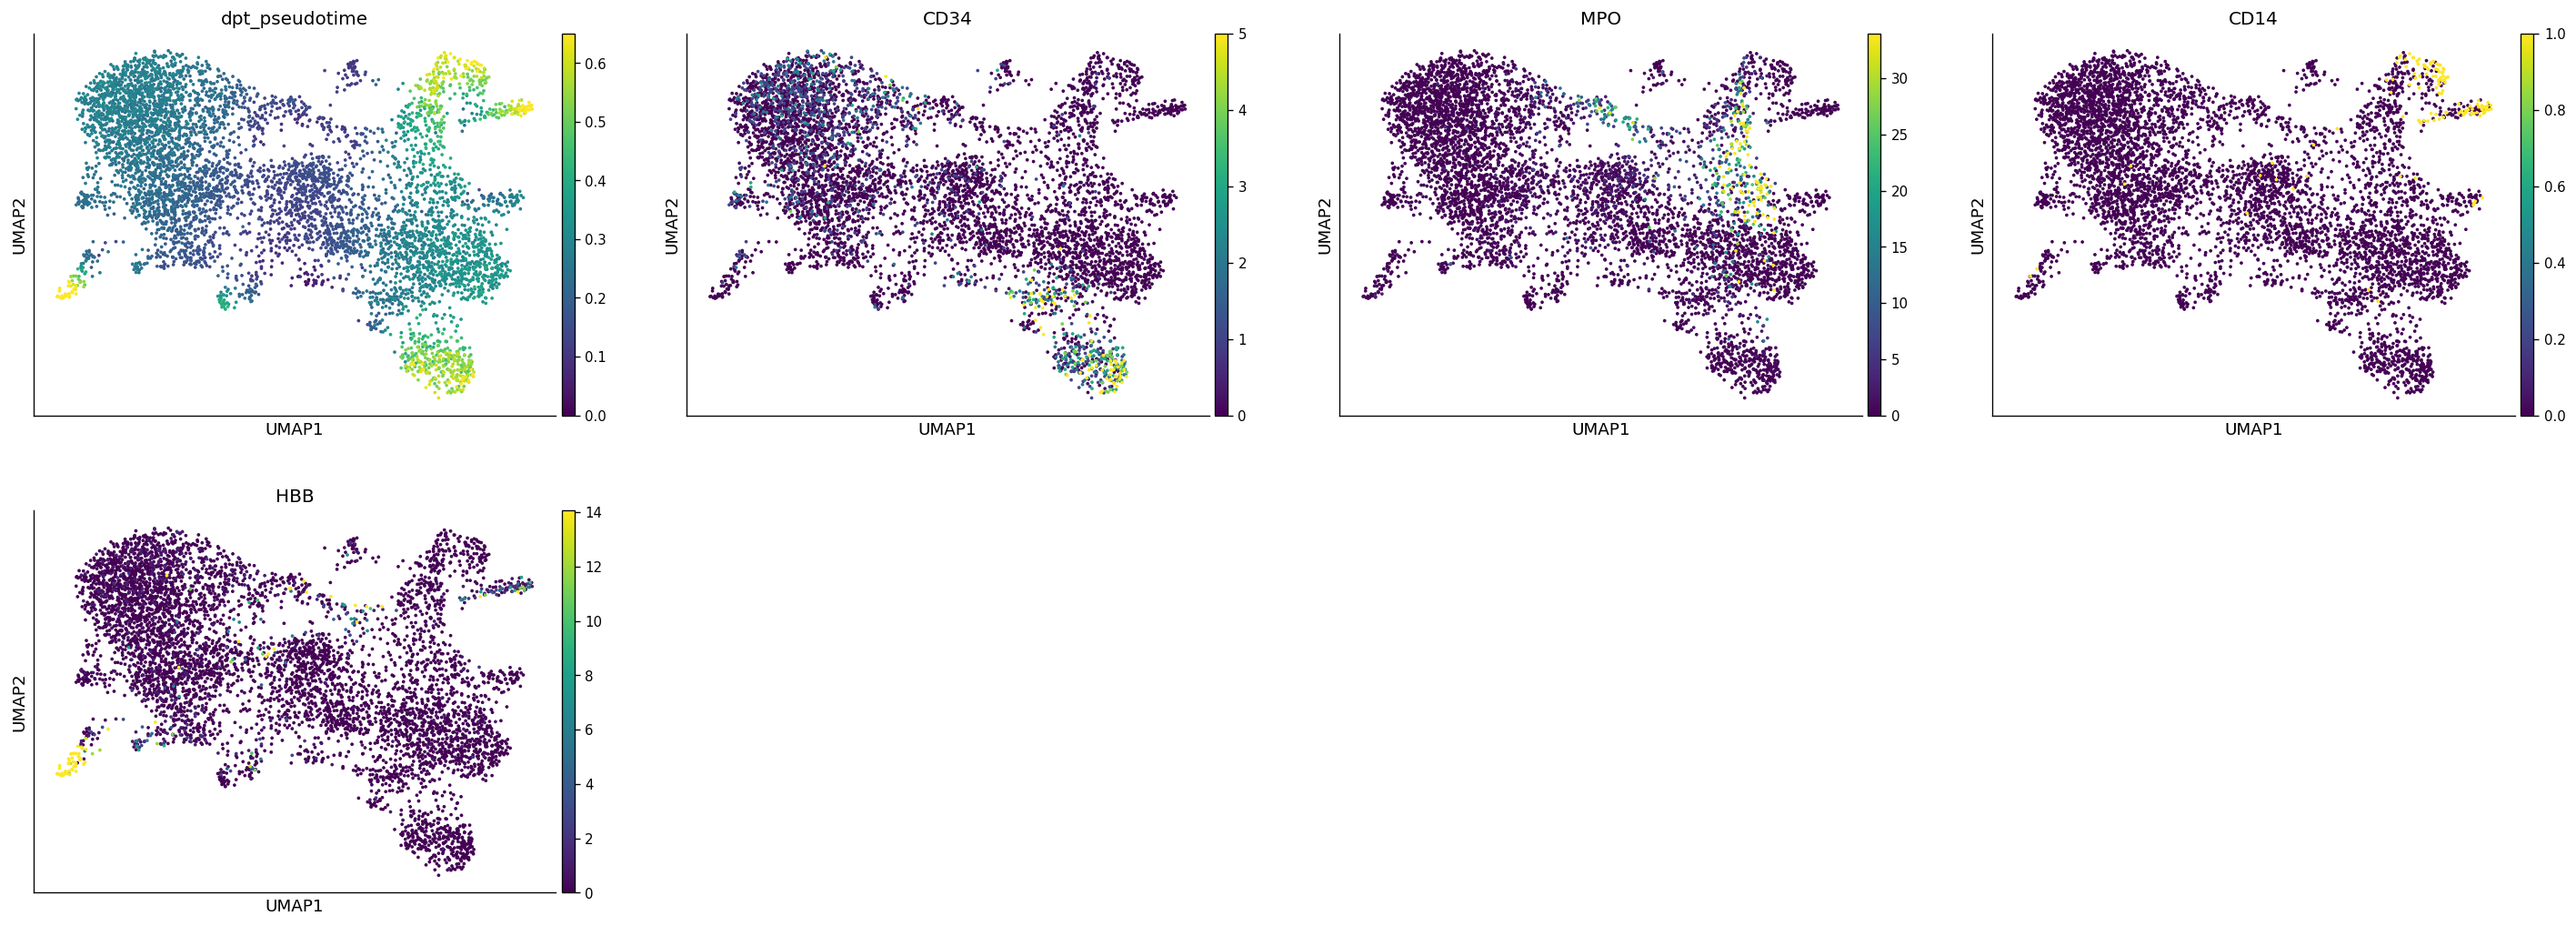

<Figure size 768x576 with 0 Axes>

In [9]:
# Gene expression along pseudotime — hematopoiesis markers
trajectory_genes = ['CD34', 'MPO', 'CD14', 'HBB']  # HSC → GMP → Mono / Erythroid
available_traj_genes = [g for g in trajectory_genes if g in adata.var_names]

if available_traj_genes:
    sc.pl.umap(adata, color=['dpt_pseudotime'] + available_traj_genes, use_raw=True, vmax='p99')
    plt.savefig('../figures/04_trajectory_gene_expression.png', dpi=150, bbox_inches='tight')

In [10]:
# Save
adata.write('../data/raw/adata_04_trajectory.h5ad')
print("Saved: ../data/raw/adata_04_trajectory.h5ad")

Saved: ../data/raw/adata_04_trajectory.h5ad


## Summary & Interpretation

| Finding | Expected result |
|---------|----------------|
| PAGA graph | Linear trajectory HSC → Mono with branches |
| AML pseudotime vs healthy | AML cells have lower pseudotime (blocked earlier) |
| CD34 expression | High at low pseudotime (progenitor marker) |
| CD14 expression | High at high pseudotime (mature monocyte marker) |

**Biological conclusion:** Malignant AML cells are blocked at the GMP/progenitor stage, consistent with the disease mechanism (differentiation arrest).

**Next:** Notebook 05 — ML classifier to distinguish malignant vs normal cells.